In [1]:
import pandas as pd
import numpy as np

# Generate example data
np.random.seed(42)

months = pd.date_range(start="2024-01-01", periods=12, freq="M")
sales = np.random.randint(100000, 300000, size=12)  # Monthly sales in GBP
profit_margin = np.random.uniform(0.15, 0.35, size=12)  # Profit as % of sales
customers = np.random.randint(700, 2500, size=12)  # Customers per month
avg_age = np.random.randint(25, 65, size=12)  # Average customer age
gender_ratio = np.random.uniform(0.4, 0.6, size=12)  # % Female customers

data = pd.DataFrame({
    "Month": months,
    "Sales_GBP": sales,
    "Profit_Margin": profit_margin,
    "Customers": customers,
    "Avg_Age": avg_age,
    "Pct_Female_Customers": gender_ratio
})

# Save to CSV
data.to_csv("Omega_UK_data.csv", index=False)
data.head()

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_2900/4018058293.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start="2024-01-01", periods=12, freq="M")


,Month,Sales_GBP,Profit_Margin,Customers,Avg_Age,Pct_Female_Customers
0,2024-01-31,221958,0.270223,1782,27,0.419534
1,2024-02-29,246867,0.291615,1210,61,0.536847
2,2024-03-31,231932,0.154117,2405,31,0.488030
3,2024-04-30,203694,0.343982,2199,45,0.424408
4,2024-05-31,219879,0.316489,1399,33,0.499035


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Omega_UK_data.csv", parse_dates=["Month"])

# View summary
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Month                 12 non-null     datetime64[ns]
 1   Sales_GBP             12 non-null     int64         
 2   Profit_Margin         12 non-null     float64       
 3   Customers             12 non-null     int64         
 4   Avg_Age               12 non-null     int64         
 5   Pct_Female_Customers  12 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 708.0 bytes


,Month,Sales_GBP,Profit_Margin,Customers,Avg_Age,Pct_Female_Customers
count,12,12.000000,12.000000,12.000000,12.000000,12.000000
mean,2024-07-15 20:00:00,218469.666667,0.237698,1650.916667,41.666667,0.484713
min,2024-01-31 00:00:00,154886.000000,0.154117,889.000000,27.000000,0.406878
25%,2024-04-22 12:00:00,208624.500000,0.191021,1355.000000,32.500000,0.444919
50%,2024-07-15 12:00:00,220918.500000,0.223619,1657.000000,40.000000,0.493533
75%,2024-10-07 18:00:00,233283.250000,0.275571,1886.250000,49.250000,0.515133
max,2024-12-31 00:00:00,268266.000000,0.343982,2405.000000,63.000000,0.581864
std,NaN,28951.106066,0.058486,462.711860,12.220202,0.053228


In [3]:
# Total sales and average profit margin
total_sales = df["Sales_GBP"].sum()
average_profit_margin = df["Profit_Margin"].mean()

print(f"Total Sales (GBP): £{total_sales:,.0f}")
print(f"Average Profit Margin: {average_profit_margin:.2%}")

Total Sales (GBP): £2,621,636
Average Profit Margin: 23.77%


In [4]:
df["Profit_GBP"] = df["Sales_GBP"] * df["Profit_Margin"]
df["Female_Customers"] = (df["Pct_Female_Customers"] * df["Customers"]).round()
df["Male_Customers"] = df["Customers"] - df["Female_Customers"]

df.head()

,Month,Sales_GBP,Profit_Margin,Customers,Avg_Age,Pct_Female_Customers,Profit_GBP,Female_Customers,Male_Customers
0,2024-01-31,221958,0.270223,1782,27,0.419534,59978.157155,748.0,1034.0
1,2024-02-29,246867,0.291615,1210,61,0.536847,71990.000613,650.0,560.0
2,2024-03-31,231932,0.154117,2405,31,0.488030,35744.640586,1174.0,1231.0
3,2024-04-30,203694,0.343982,2199,45,0.424408,70067.063485,933.0,1266.0
4,2024-05-31,219879,0.316489,1399,33,0.499035,69589.181083,698.0,701.0


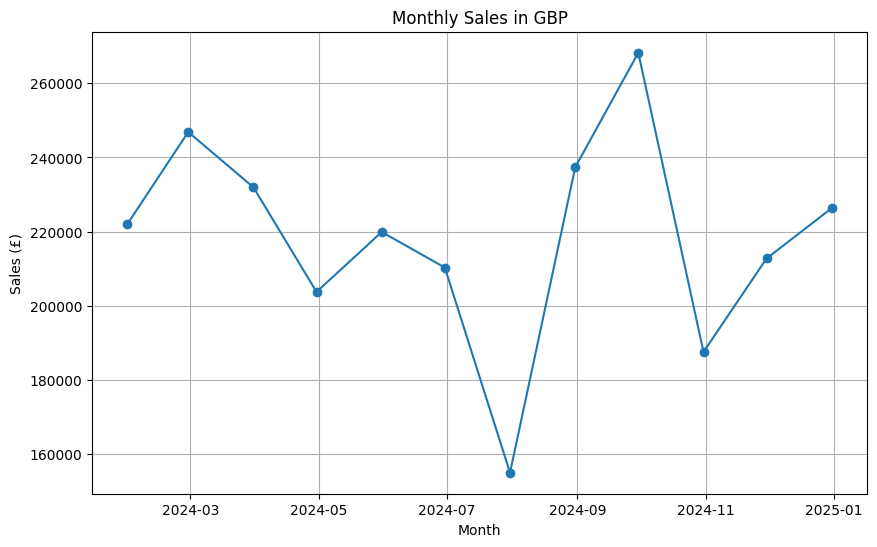

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df["Month"], df["Sales_GBP"], marker="o")
plt.title("Monthly Sales in GBP")
plt.xlabel("Month")
plt.ylabel("Sales (£)")
plt.grid(True)
plt.show()

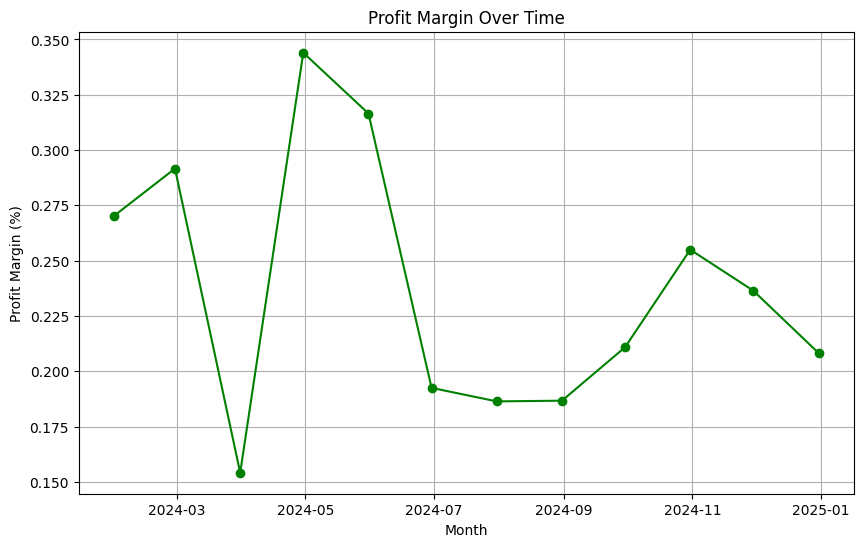

In [6]:
plt.figure(figsize=(10,6))
plt.plot(df["Month"], df["Profit_Margin"], marker="o", color="green")
plt.title("Profit Margin Over Time")
plt.xlabel("Month")
plt.ylabel("Profit Margin (%)")
plt.grid(True)
plt.show()

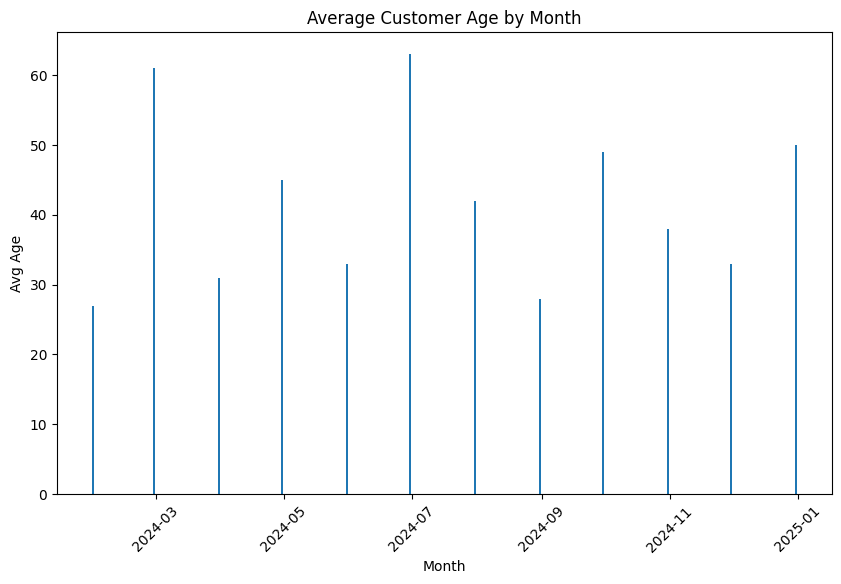

In [7]:
plt.figure(figsize=(10,6))
plt.bar(df["Month"], df["Avg_Age"])
plt.title("Average Customer Age by Month")
plt.xlabel("Month")
plt.ylabel("Avg Age")
plt.xticks(rotation=45)
plt.show()

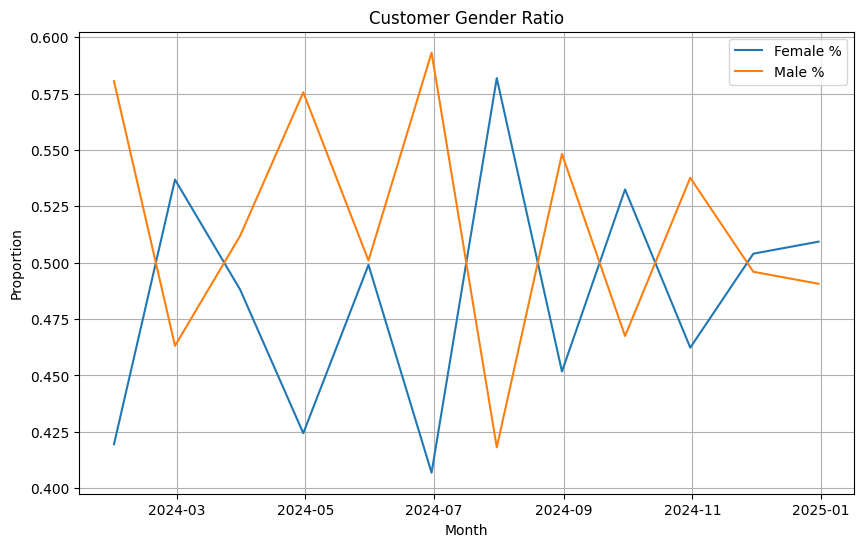

In [8]:
plt.figure(figsize=(10,6))
plt.plot(df["Month"], df["Pct_Female_Customers"], label="Female %")
plt.plot(df["Month"], 1 - df["Pct_Female_Customers"], label="Male %")
plt.title("Customer Gender Ratio")
plt.xlabel("Month")
plt.ylabel("Proportion")
plt.legend()
plt.grid(True)
plt.show()